In [105]:
import gfapy
import networkx as nx
import numpy as np
from dimod import CQM, Binary

In [106]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into an oriented graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for segment_line in gfa.segments:
        graph.add_node(f'{segment_line.name}_+', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
        graph.add_node(f'{segment_line.name}_-', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        graph.add_edges_from([
            (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
        ])
        v1.invert()
        v2.invert()
        graph.add_edges_from([
            (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
        ])
    return graph

def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

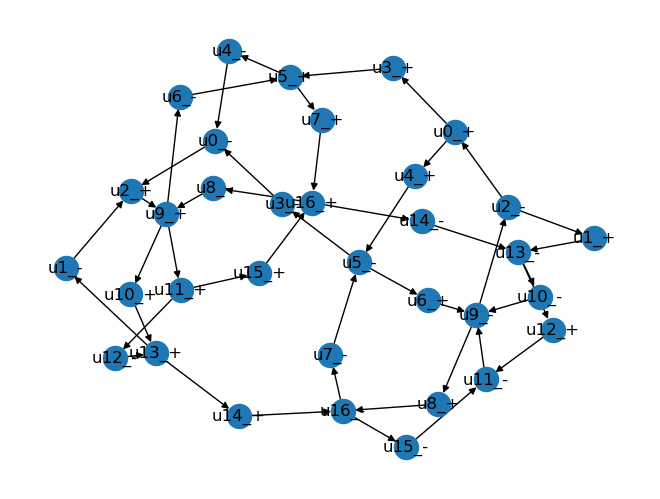

In [107]:
# g = oriented_graph_from_file('../../data/test.gfa')
g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k501.utg.final.gfa')
g = normalise_node_weights(g, 100)
nx.draw_kamada_kawai(g, with_labels=True)

In [108]:
nodes = list(g.nodes)
V = int(len(nodes) / 2)
total_weight = int(sum(g.nodes[node]["weight"] for node in nodes) / 2)
alpha = 1.2
T_max = int(total_weight * alpha)
qubo_matrix = np.zeros((T_max, V + 1, 2, T_max, V + 1, 2))

lambda_t = 4 * T_max
lambda_g = T_max
lambda_end = 2 * T_max
lambda_w = 1 * T_max

In [109]:
variables_array_shape = (T_max, V + 1, 2)
def var_index(multi_index):
    return np.ravel_multi_index(multi_index, variables_array_shape)

In [110]:
cqm = CQM()
variables = [Binary(i) for i in range(T_max * (V+1) * 2)]
obj = cqm.set_objective(
    - lambda_g * sum(
        variables[var_index((t, i, bi))] * variables[var_index((t + 1, j, bj))] if (nodes[2 * i + bi], nodes[2 * j + bj]) in g.edges else 0
        for t in range(T_max - 1) 
        for i in range(V) for j in range(V)
        for bi in range(2) for bj in range(2)
    )
    - (lambda_g - 1) * sum(
        sum(variables[var_index((t, i, bi))] * variables[var_index((t + 1, V, 0))] for i in range(V) for bi in range(2))
        + variables[var_index((t, V, 0))] * variables[var_index((t + 1, V, 0))]
        for t in range(T_max - 1) 
    )
    + lambda_w * sum(
        (g.nodes[nodes[2 * i]]["weight"] - sum(variables[var_index((t, i, 0))] + variables[var_index((t, i, 1))] for t in range(T_max))) ** 2
        for i in range(V)
    )
)

In [111]:
# Extra end node constraints
# end_node_constraints = []
# for t in range(T_max):
#     end_node_constraints.append(cqm.add_constraint_from_iterable(
#         [(var_index((t, V, 1)), 1)],
#         sense='==',
#         rhs=0
#     ))

# Path constraints
t_constraints = []
for t in range(T_max):
    t_constraints.append(cqm.add_constraint_from_iterable(
        [(var_index((t, i, b)), 1) for i in range(V) for b in range(2)] + [(var_index((t, V, 0)), 1)],
        sense='==',
        rhs=1
    ))

# Don't leave end constraints
end_constraints = []
for t in range(T_max - 1):
    end_constraints.append(cqm.add_constraint_from_iterable(
         [(var_index((t, V, 0)), (var_index((t + 1, i, b))), 1) for i in range(V) for b in range(2)],
         sense='==',
         rhs=0
    ))



In [112]:
print(cqm.variables)
print(cqm.num_biases())

Variables([1, 40, 0, 42, 44, 3, 2, 63, 5, 36, 38, 4, 54, 7, 37, 6, 46, 9, 8, 47, 11, 43, 10, 45, 48, 50, 13, 12, 55, 15, 14, 68, 17, 16, 69, 19, 41, 18, 49, 52, 56, 58, 21, 20, 62, 23, 22, 61, 66, 24, 59, 25, 26, 39, 27, 57, 60, 64, 29, 28, 31, 30, 33, 51, 32, 53, 65, 67, 76, 78, 80, 99, 72, 74, 90, 73, 82, 83, 79, 81, 84, 86, 91, 104, 105, 77, 85, 88, 92, 94, 98, 97, 102, 95, 75, 93, 96, 100, 87, 89, 101, 103, 112, 114, 116, 135, 108, 110, 126, 109, 118, 119, 115, 117, 120, 122, 127, 140, 141, 113, 121, 124, 128, 130, 134, 133, 138, 131, 111, 129, 132, 136, 123, 125, 137, 139, 148, 150, 152, 171, 144, 146, 162, 145, 154, 155, 151, 153, 156, 158, 163, 176, 177, 149, 157, 160, 164, 166, 170, 169, 174, 167, 147, 165, 168, 172, 159, 161, 173, 175, 184, 186, 188, 207, 180, 182, 198, 181, 190, 191, 187, 189, 192, 194, 199, 212, 213, 185, 193, 196, 200, 202, 206, 205, 210, 203, 183, 201, 204, 208, 195, 197, 209, 211, 220, 222, 224, 243, 216, 218, 234, 217, 226, 227, 223, 225, 228, 230, 235, 

In [113]:
cqm.constraints[end_constraints[1]].to_polystring()
cqm.objective.to_polystring()

'1760 - 96*v1 - 160*v40 - 96*v0 - 32*v42 - 32*v44 - 32*v3 - 32*v2 - 96*v63 - 160*v5 - 96*v36 - 32*v38 - 160*v4 - 224*v54 - 32*v7 - 96*v37 - 32*v6 - 96*v46 - 32*v9 - 32*v8 - 96*v47 - 96*v11 - 32*v43 - 96*v10 - 32*v45 - 32*v48 - 32*v50 - 32*v13 - 32*v12 - 224*v55 - 32*v15 - 32*v14 - 96*v68 - 32*v17 - 32*v16 - 96*v69 - 224*v19 - 160*v41 - 224*v18 - 32*v49 - 32*v52 - 32*v56 - 96*v58 - 32*v21 - 32*v20 - 96*v62 - 96*v23 - 96*v22 - 32*v61 - 32*v66 - 32*v24 - 96*v59 - 32*v25 - 96*v26 - 32*v39 - 96*v27 - 32*v57 - 32*v60 - 32*v64 - 32*v29 - 32*v28 - 32*v31 - 32*v30 - 96*v33 - 32*v51 - 96*v32 - 32*v53 - 32*v65 - 32*v67 - 160*v76 - 32*v78 - 32*v80 - 96*v99 - 96*v72 - 32*v74 - 224*v90 - 96*v73 - 96*v82 - 96*v83 - 32*v79 - 32*v81 - 32*v84 - 32*v86 - 224*v91 - 96*v104 - 96*v105 - 160*v77 - 32*v85 - 32*v88 - 32*v92 - 96*v94 - 96*v98 - 32*v97 - 32*v102 - 96*v95 - 32*v75 - 32*v93 - 32*v96 - 32*v100 - 32*v87 - 32*v89 - 32*v101 - 32*v103 - 160*v112 - 32*v114 - 32*v116 - 96*v135 - 96*v108 - 32*v110 - 224*v

In [114]:
from dwave.system import LeapHybridCQMSampler
sampler = LeapHybridCQMSampler()  

In [115]:
sampleset = sampler.sample_cqm(cqm, time_limit=20, label="CQM Oriented Test")  
print("{} feasible solutions of {}.".format(sampleset.record.is_feasible.sum(), len(sampleset))) 

131 feasible solutions of 149.


In [116]:
best = sampleset.filter(lambda row: row.is_feasible).first
best

Sample(sample={0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.0, 20: 0.0, 21: 0.0, 22: 0.0, 23: 0.0, 24: 0.0, 25: 0.0, 26: 0.0, 27: 1.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.0, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 0.0, 51: 0.0, 52: 0.0, 53: 0.0, 54: 0.0, 55: 0.0, 56: 0.0, 57: 0.0, 58: 0.0, 59: 0.0, 60: 1.0, 61: 0.0, 62: 0.0, 63: 0.0, 64: 0.0, 65: 0.0, 66: 0.0, 67: 0.0, 68: 0.0, 69: 0.0, 70: 0.0, 72: 0.0, 73: 0.0, 74: 0.0, 75: 0.0, 76: 0.0, 77: 0.0, 78: 0.0, 79: 0.0, 80: 0.0, 81: 0.0, 82: 0.0, 83: 0.0, 84: 0.0, 85: 0.0, 86: 0.0, 87: 0.0, 88: 0.0, 89: 0.0, 90: 0.0, 91: 0.0, 92: 0.0, 93: 0.0, 94: 0.0, 95: 1.0, 96: 0.0, 97: 0.0, 98: 0.0, 99: 0.0, 100: 0.0, 101: 0.0, 102: 0.0, 103: 0.0, 104: 0.0, 105: 0.0, 106: 0.0, 108: 0.0, 109: 0.0, 110: 0.0, 111: 0.0, 112

In [117]:
def sample_to_path(sample):
    path = []
    for key, val in sample.items():
        if val == 1.0:
            multi_index = np.unravel_index(key, (T_max, V+1, 2))
            path.append((multi_index[0], nodes[2 * multi_index[1] + multi_index[2]] if multi_index[1] < V else 'end'))
    return path

In [119]:
path = sample_to_path(best.sample)
for p in path:
    print(p)

(0, 'u13_-')
(1, 'u12_+')
(2, 'u11_-')
(3, 'u9_-')
(4, 'u8_+')
(5, 'u16_-')
(6, 'u7_-')
(7, 'u5_-')
(8, 'u3_-')
(9, 'u0_-')
(10, 'u2_+')
(11, 'u9_+')
(12, 'u10_+')
(13, 'u13_+')
(14, 'u14_+')
(15, 'u16_-')
(16, 'u15_-')
(17, 'u11_-')
(18, 'u9_-')
(19, 'u2_-')
(20, 'u0_+')
(21, 'u4_+')
(22, 'u5_-')
(23, 'u6_+')
(24, 'u9_-')
(25, 'u2_-')
(26, 'u1_+')
(27, 'end')
(28, 'end')
(29, 'end')
(30, 'end')
(31, 'end')


In [120]:
cqm.energy(best.sample)

AttributeError: 'ConstrainedQuadraticModel' object has no attribute 'energy'